# Solutions · Coding Exercise 2: Composition and Control

Every part solved, run, and explained plainly. Two ideas about control:

- a pipe can **fan out**, running several steps on the same input, then merge
- an agent can return a **typed object** instead of prose, so the next line of code can trust it

Runs with no credentials. The model is a scripted stand-in, the LangChain code is real. Structured output needs the live model, so those parts show the real call plus a runnable validation stand-in.

```python
# The only change for the live lab:
from langchain_aws import ChatBedrockConverse
model = ChatBedrockConverse(model="us.anthropic.claude-haiku-4-5-20251001-v1:0", region_name="us-east-1", temperature=0)
```

### Setup

Run this first.

In [1]:
from typing import Any, List
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import AIMessage
from langchain_core.outputs import ChatResult, ChatGeneration
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableParallel, RunnableLambda
from pydantic import BaseModel, Field, ValidationError


class ScriptedChatModel(BaseChatModel):
    '''Deterministic stand-in so this notebook runs offline.
    The framework code is real. Swap for ChatBedrockConverse on the lab.'''
    responses: List[Any]
    idx: int = 0

    @property
    def _llm_type(self) -> str:
        return "scripted"

    def _generate(self, messages, stop=None, run_manager=None, **kwargs):
        reply = self.responses[min(self.idx, len(self.responses) - 1)]
        object.__setattr__(self, "idx", self.idx + 1)
        return ChatResult(generations=[ChatGeneration(message=reply)])

    def bind_tools(self, tools, **kwargs):
        return self


print("ready")

ready


---
## Part 1 · A parallel pipe

**The picture.** One input feeds two branches. They run on the same input, merge into a dict, and a final step formats one line.

```mermaid
flowchart TD
    IN[pnr] --> S[status branch]
    IN --> T[tier branch]
    S --> MERGE[merge into a dict]
    T --> MERGE
    MERGE --> F[format one line]
```

**Layman version.** You hand one clerk a passenger name. Two assistants look up two different facts at the same time, drop both on the clerk's desk, and the clerk writes one summary line. Nobody waits in line behind anybody.

**The solution:** two `RunnableLambda` branches, `RunnableParallel` to run them together, a format step, composed with `|`.

In [2]:
BOOKINGS = {"JX48Q2": {"status": "BLR-DEL cancelled", "tier": "Gold"}}

status_branch = RunnableLambda(lambda d: BOOKINGS[d["pnr"]]["status"])
tier_branch = RunnableLambda(lambda d: BOOKINGS[d["pnr"]]["tier"])

fan_out = RunnableParallel(status=status_branch, tier=tier_branch)

format_step = RunnableLambda(
    lambda d: f"JX48Q2: {d['status']}, {d['tier']} tier, no rebooking fee."
)

chain = fan_out | format_step
print("merged dict:", fan_out.invoke({"pnr": "JX48Q2"}))
print("final line :", chain.invoke({"pnr": "JX48Q2"}))

merged dict: {'status': 'BLR-DEL cancelled', 'tier': 'Gold'}
final line : JX48Q2: BLR-DEL cancelled, Gold tier, no rebooking fee.


**What happened:**

- both branches received the same input, `{"pnr": "JX48Q2"}`
- `RunnableParallel` returned a dict keyed by branch name, `{"status": ..., "tier": ...}`
- `format_step` read that dict and built the sentence

No model touched this pipe. It is pure composition, and it is the parallelization pattern in three lines.

### A small intuition: sequential vs parallel stages

Running two independent lookups one after another means waiting through both. Running them together collapses the wait. Numbers below are illustrative, to show the shape.

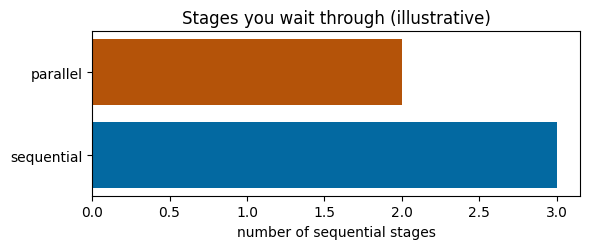

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 2.6))
plt.barh(["sequential", "parallel"], [3, 2], color=["#0369A1", "#B45309"])
plt.title("Stages you wait through (illustrative)")
plt.xlabel("number of sequential stages")
plt.tight_layout()
plt.show()

---
## Part 2 · An agent with structured output

**The picture.** The agent returns a validated object, not a paragraph. Code can branch on real fields.

```mermaid
flowchart LR
    U[status of JX48Q2?] --> AG[agent with response_format] --> OBJ[validated Disruption object]
```

**Layman version.** You do not want a friendly paragraph you have to squint at. You want a form with the boxes filled in and checked, so the next step can act without guessing.

**The solution (live lab).** Pass `response_format=Disruption`, then read `result["structured_response"]`.

```python
# Runs on the lab (needs Bedrock):
agent = create_agent(model, tools=[], response_format=Disruption, system_prompt="You are TravelMind.")
result = agent.invoke({"messages": [{"role": "user", "content": "Status of JX48Q2? Rao is Gold tier."}]})
obj = result["structured_response"]          # a validated Disruption
print(obj.pnr, obj.status, obj.rebook_fee_waived)
```

Below, the same idea shown runnably: the model produced JSON, and validation turns it into a trusted object or a clear error.

In [3]:
class Disruption(BaseModel):
    pnr: str = Field(description="the passenger name record")
    status: str = Field(description="cancelled, delayed, or on-time")
    rebook_fee_waived: bool = Field(description="true if the passenger is Gold tier")


# A good payload becomes a typed object you can branch on.
good = '{"pnr": "JX48Q2", "status": "cancelled", "rebook_fee_waived": true}'
obj = Disruption.model_validate_json(good)
print("typed object:", obj)
print("branch on a real bool:", "no fee" if obj.rebook_fee_waived else "fee applies")

# A bad payload fails at the boundary, naming the missing field.
bad = '{"pnr": "JX48Q2", "status": "cancelled"}'
try:
    Disruption.model_validate_json(bad)
except ValidationError as e:
    print("rejected:", e.errors()[0]["loc"][0], "->", e.errors()[0]["msg"])

typed object: pnr='JX48Q2' status='cancelled' rebook_fee_waived=True
branch on a real bool: no fee
rejected: rebook_fee_waived -> Field required


**Why this beats "reply in JSON":**

- a missing or wrong-typed field fails at parse, not three functions later
- the boolean is a real `bool`, so `if obj.rebook_fee_waived` works, no string parsing

> **Skeptic's corner.** "Usually valid JSON" is a bug generator. The schema plus validation is what turns "usually" into "guaranteed, or a clear error." Never trust unvalidated model output in code.

---
## Part 3 · Debug and fix a broken pipe

Two faults. Named and corrected.

```mermaid
flowchart LR
    B1[model then prompt then parser] --> F1[prompt then model then parser]
    B2[invoke a bare string] --> F2[invoke a dict of variables]
```

| Line | Fault | Fix |
|---|---|---|
| L5 | pipe composed in the wrong order | put `prompt` first, then `model`, then the parser |
| L6 | wrong input shape | `chain.invoke({"pnr": "JX48Q2"})` |

The corrected, running version:

In [4]:
prompt = ChatPromptTemplate.from_template("Summarise the disruption for {pnr} in one line.")
model = ScriptedChatModel(responses=[AIMessage(content="JX48Q2 is cancelled on BLR-DEL.")])

chain = prompt | model | StrOutputParser()   # prompt first, model, then parser
print(chain.invoke({"pnr": "JX48Q2"}))       # fill the template variable with a dict

JX48Q2 is cancelled on BLR-DEL.


**Why order matters.** Each stage expects a certain input:

- the prompt expects your variables and outputs messages
- the model expects messages and outputs an `AIMessage`
- the parser expects an `AIMessage` and outputs a string

Put the model first and it receives a template, which is not messages, so it breaks. The template variable is filled from a dict, not a bare string.

---
## Part 4 · Strands to LangChain, structured output

Strands exposes structured output as a separate method. LangChain folds it into the agent result under `structured_response`. The Pydantic model does not change.

| Strands | LangChain |
|---|---|
| `Agent(model=, system_prompt=)` | `create_agent(model, tools=[], system_prompt=)` |
| `agent.structured_output(Rebooking, "...")` | agent with `response_format=Rebooking`, then `result["structured_response"]` |
| `result.new_flight` | `obj.new_flight` |

**The LangChain solution (live lab):**

```python
class Rebooking(BaseModel):
    pnr: str
    new_flight: str
    fee: float

agent = create_agent(model, tools=[], response_format=Rebooking, system_prompt="You are TravelMind.")
result = agent.invoke({"messages": [{"role": "user", "content": "Rebook JX48Q2 onto AI-506, no fee for Gold."}]})
obj = result["structured_response"]          # a validated Rebooking
print(obj.new_flight)
```

The runnable validation stand-in, proving the object your code receives:

In [6]:
class Rebooking(BaseModel):
    pnr: str
    new_flight: str
    fee: float


produced = '{"pnr": "JX48Q2", "new_flight": "AI-506", "fee": 0.0}'
obj = Rebooking.model_validate_json(produced)
print("new_flight:", obj.new_flight)
print("fee is a real float:", obj.fee, type(obj.fee).__name__)

new_flight: AI-506
fee is a real float: 0.0 float


---
## Part 5 · An agent inside a pipe

**The picture.** Wrap the agent as a pipe step so it composes with everything else.

```mermaid
flowchart LR
    IN[pnr] --> Q[build a question string] --> AG[agent step] --> TXT[final text]
```

**The solution:** two `RunnableLambda` steps, one building the question, one running the agent and returning its final text.

In [7]:
BOOKINGS = {"JX48Q2": "BLR-DEL cancelled, Rao, Gold tier"}


@tool
def lookup_pnr(pnr: str) -> str:
    '''Return the booking status for a PNR when the user asks about a booking.'''
    return BOOKINGS.get(pnr, "PNR not found")


model = ScriptedChatModel(responses=[
    AIMessage(content="", tool_calls=[{"name": "lookup_pnr", "args": {"pnr": "JX48Q2"}, "id": "t1", "type": "tool_call"}]),
    AIMessage(content="JX48Q2 on BLR-DEL is cancelled. Gold tier, no fee."),
])
agent = create_agent(model, tools=[lookup_pnr], system_prompt="You are TravelMind.")

build_question = RunnableLambda(lambda d: f"Status of {d['pnr']}?")
ask_agent = RunnableLambda(lambda q: agent.invoke({"messages": [{"role": "user", "content": q}]})["messages"][-1].content)

chain = build_question | ask_agent
print(chain.invoke({"pnr": "JX48Q2"}))

JX48Q2 on BLR-DEL is cancelled. Gold tier, no fee.


**What happened:**

- `build_question` formatted the PNR into a question
- `ask_agent` ran the agent and returned only the final text
- the `|` joined them into one chain

Anything wrapped in `RunnableLambda` becomes composable, so an agent, a model, and a plain function all sit in the same `|` chain. That is the whole point of LCEL: one uniform way to connect pieces.

---
## What this exercise practised

- turned a fan-out diagram into a parallel pipe with `RunnableParallel`
- made an agent return a validated object instead of prose
- fixed the two bugs that break most first pipes: wrong order and wrong input shape
- ported a Strands structured-output call to LangChain
- placed an agent inside an LCEL pipe as a composable step

> **Forward look.** Fan-out, typed output, and composition are not framework trivia. They are how you keep an agent system fast, trustworthy, and easy to reason about as it grows. Reach for structure when a simpler version has actually failed you, not before.